<a href="https://colab.research.google.com/github/Souvik-kundu-off/Student_Performance_Prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction Project

## Project Overview
This project aims to predict student performance (final grade G3) and classify students as 'Pass' or 'Fail' based on various demographic, social, and school-related features. The dataset is sourced from the UCI Machine Learning Repository, focusing on student performance in secondary education in two Portuguese schools.

## Key Steps:
1.  **Data Preprocessing**: Handling categorical features, creating a target variable for classification, and splitting data for training and testing.
2.  **Exploratory Data Analysis (EDA)**: Visualizing data distributions, correlations, and relationships between features and target variables.
3.  **Model Training**: Developing both regression and classification models to predict G3 and pass/fail status, respectively.
4.  **Feature Importance**: Identifying the most influential features for predictions.
5.  **Interactive Frontend**: A user-friendly interface to predict student performance based on input features.

## Data Preprocessing Summary
-   **Data Loading**: Used `ucimlrepo` to fetch the 'Student Performance' dataset.
-   **Target Variable Creation**: Created a binary `pass_fail` variable (1 for G3 >= 10, 0 otherwise).
-   **Handling Categorical Features**: Applied `LabelEncoder` for binary categorical variables and `pd.get_dummies` (one-hot encoding) for multi-category nominal variables.
-   **Data Splitting**: Split data into training and testing sets (80/20 ratio, `random_state=42`) for both regression (predicting G3) and classification (predicting pass/fail, with stratification).
-   **Feature Scaling**: Numerical features were scaled using `StandardScaler`.

## Exploratory Data Analysis (EDA) Summary
Key visualizations revealed:
-   Distribution of `G3` scores, showing common grade ranges.
-   Proportion of students passing vs. failing.
-   Correlation heatmap of numerical features, highlighting relationships.
-   Top 10 features most correlated with `G3` (excluding `G1` and `G2`), with `failures` showing a strong negative correlation and `higher` a positive one.
-   Box plots illustrated the impact of `studytime`, `failures`, and `absences` on `G3`.
-   Insights into gender-wise average `G3` and the influence of parental education levels.

## Model Architecture and Results

### Regression Models (Predicting G3)
-   **Models Evaluated**: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor.
-   **Metrics**: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2) score.
-   **Best Model**: **Gradient Boosting Regressor** achieved the highest R2 score of **0.2246**, indicating it best explains the variance in `G3`.

### Classification Models (Predicting Pass/Fail)
-   **Models Evaluated**: Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier, Support Vector Machine (SVM).
-   **Metrics**: Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
-   **Best Model**: **Support Vector Machine (SVM)** achieved the highest F1-score of **0.8966**, demonstrating a strong balance between precision and recall for classifying pass/fail status.

All trained models (`best_regression_model.joblib` and `best_classification_model.joblib`) were saved using `joblib`.

## Feature Importance Summary
-   **Random Forest Feature Importances**: For both regression and classification, `failures` consistently appeared as a highly important feature. For classification, `higher` (desire for higher education) and `school` also played significant roles.
-   **SHAP (SHapley Additive exPlanations) Summary Plot**: Generated for the best classification model (SVM), the SHAP plot provided deeper insights into how each feature influences the model's output, indicating which features drive predictions towards 'pass' or 'fail'.

## Interactive Frontend (ipywidgets)
An interactive user interface was developed using `ipywidgets` to allow real-time predictions based on user-inputted student information. This frontend:
-   Provides various input widgets (radio buttons, dropdowns, sliders) for student features.
-   Transforms input data to match model training format.
-   Uses the best regression model to predict `G3` and the best classification model to predict pass/fail status.
-   Displays predicted `G3`, pass/fail status, and classification confidence with a visual progress bar.

## Conclusion
This project successfully developed and evaluated machine learning models for student performance prediction. The Gradient Boosting Regressor and SVM were identified as the best-performing models for regression and classification tasks, respectively. Feature importance analysis provided valuable insights into critical factors influencing student outcomes. The interactive frontend serves as a practical tool for quick assessment, demonstrating the real-world application of the developed models.

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

print(student_performance.metadata)

print(student_performance.variables)

{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

# Student Performance Prediction Project

## Project Overview
This project aims to predict student performance (final grade G3) and classify students as 'Pass' or 'Fail' based on various demographic, social, and school-related features. The dataset is sourced from the UCI Machine Learning Repository, focusing on student performance in secondary education in two Portuguese schools.

## Key Steps:
1.  **Data Preprocessing**: Handling categorical features, creating a target variable for classification, and splitting data for training and testing.
2.  **Exploratory Data Analysis (EDA)**: Visualizing data distributions, correlations, and relationships between features and target variables.
3.  **Model Training**: Developing both regression and classification models to predict G3 and pass/fail status, respectively.
4.  **Feature Importance**: Identifying the most influential features for predictions.
5.  **Interactive Frontend**: A user-friendly interface to predict student performance based on input features.

In [ ]:
!pip install scikit-learn pandas matplotlib seaborn shap ipywidgets joblib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.4 MB/s eta 0:00:00


## 1. DATA PREPROCESSING

## Data Preprocessing Summary
-   **Data Loading**: Used `ucimlrepo` to fetch the 'Student Performance' dataset.
-   **Target Variable Creation**: Created a binary `pass_fail` variable (1 for G3 >= 10, 0 otherwise).
-   **Handling Categorical Features**: Applied `LabelEncoder` for binary categorical variables and `pd.get_dummies` (one-hot encoding) for multi-category nominal variables.
-   **Data Splitting**: Split data into training and testing sets (80/20 ratio, `random_state=42`) for both regression (predicting G3) and classification (predicting pass/fail, with stratification).
-   **Feature Scaling**: Numerical features were scaled using `StandardScaler`.

## Feature Descriptions
Understanding the features is crucial for interpreting the model's predictions. Below is a summary of some key features in the dataset:

*   **school**: Student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira).
*   **sex**: Student's sex (binary: 'F' - female or 'M' - male).
*   **age**: Student's age (numeric: from 15 to 22).
*   **address**: Student's home address type (binary: 'U' - urban or 'R' - rural).
*   **famsize**: Family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3).
*   **Pstatus**: Parent's cohabitation status (binary: 'T' - living together or 'A' - apart).
*   **Medu**: Mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education).
*   **Fedu**: Father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education).
*   **Mjob**: Mother's job (nominal: 'teacher', 'health' care related, civil 'services', 'at_home' or 'other').
*   **Fjob**: Father's job (nominal: 'teacher', 'health' care related, civil 'services', 'at_home' or 'other').
*   **reason**: Reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other').
*   **guardian**: Student's guardian (nominal: 'mother', 'father' or 'other').
*   **traveltime**: Home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour).
*   **studytime**: Weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours).
*   **failures**: Number of past class failures (numeric: n if 1<=n<3, else 4).
*   **schoolsup**: Extra educational support (binary: yes or no).
*   **famsup**: Family educational support (binary: yes or no).
*   **paid**: Extra paid classes within the course subject (Math or Portuguese) (binary: yes or no).
*   **activities**: Extra-curricular activities (binary: yes or no).
*   **nursery**: Attended nursery school (binary: yes or no).
*   **higher**: Wants to take higher education (binary: yes or no).
*   **internet**: Internet access at home (binary: yes or no).
*   **romantic**: With a romantic relationship (binary: yes or no).
*   **famrel**: Quality of family relationships (numeric: from 1 - very bad to 5 - excellent).
*   **freetime**: Free time after school (numeric: from 1 - very low to 5 - very high).
*   **goout**: Going out with friends (numeric: from 1 - very low to 5 - very high).
*   **Dalc**: Workday alcohol consumption (numeric: from 1 - very low to 5 - very high).
*   **Walc**: Weekend alcohol consumption (numeric: from 1 - very low to 5 - very high).
*   **health**: Current health status (numeric: from 1 - very bad to 5 - very good).
*   **absences**: Number of school absences (numeric: from 0 to 93).
*   **G1**: First period grade (numeric: from 0 to 20).
*   **G2**: Second period grade (numeric: from 0 to 20).
*   **G3**: Final grade (numeric: from 0 to 20; target variable).

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

y = y.reset_index(drop=True)
df = pd.concat([X, y], axis=1)

print("Original DataFrame head:")
display(df.head())
print("\nOriginal DataFrame info:")
df.info()

Original DataFrame head:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null

In [ ]:
print("Missing values before handling:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nMissing values after handling (if any):")
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before handling:


,0



Missing values after handling (if any):


,0


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

numerical_cols = numerical_cols.drop(['G1', 'G2', 'G3'], errors='ignore')

df_encoded = df.copy()

for col in categorical_cols:
    if df[col].nunique() == 2:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        print(f"Label encoded column: {col}, Mapped to: {{'0': {le.classes_[0]}, '1': {le.classes_[1]}}}")
    else:
        df_encoded[col] = df_encoded[col].astype('category')
        df_encoded = pd.get_dummies(df_encoded, columns=[col], prefix=col, drop_first=True)
        print(f"One-hot encoded column: {col}")


print("\nDataFrame head after encoding:")
display(df_encoded.head())
print("\nDataFrame info after encoding:")
df_encoded.info()

Label encoded column: school, Mapped to: {'0': GP, '1': MS}
Label encoded column: sex, Mapped to: {'0': F, '1': M}
Label encoded column: address, Mapped to: {'0': R, '1': U}
Label encoded column: famsize, Mapped to: {'0': GT3, '1': LE3}
Label encoded column: Pstatus, Mapped to: {'0': A, '1': T}
One-hot encoded column: Mjob
One-hot encoded column: Fjob
One-hot encoded column: reason
One-hot encoded column: guardian
Label encoded column: schoolsup, Mapped to: {'0': no, '1': yes}
Label encoded column: famsup, Mapped to: {'0': no, '1': yes}
Label encoded column: paid, Mapped to: {'0': no, '1': yes}
Label encoded column: activities, Mapped to: {'0': no, '1': yes}
Label encoded column: nursery, Mapped to: {'0': no, '1': yes}
Label encoded column: higher, Mapped to: {'0': no, '1': yes}
Label encoded column: internet, Mapped to: {'0': no, '1': yes}
Label encoded column: romantic, Mapped to: {'0': no, '1': yes}

DataFrame head after encoding:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,0,0,17,1,0,1,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,0,0,15,1,1,1,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,0,0,15,1,0,1,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,0,0,16,1,0,1,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False



DataFrame info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   school             649 non-null    int64
 1   sex                649 non-null    int64
 2   age                649 non-null    int64
 3   address            649 non-null    int64
 4   famsize            649 non-null    int64
 5   Pstatus            649 non-null    int64
 6   Medu               649 non-null    int64
 7   Fedu               649 non-null    int64
 8   traveltime         649 non-null    int64
 9   studytime          649 non-null    int64
 10  failures           649 non-null    int64
 11  schoolsup          649 non-null    int64
 12  famsup             649 non-null    int64
 13  paid               649 non-null    int64
 14  activities         649 non-null    int64
 15  nursery            649 non-null    int64
 16  higher             649 non-nul

In [ ]:
df_encoded['pass_fail'] = (df_encoded['G3'] >= 10).astype(int)

print("Counts for 'pass_fail' column:")
display(df_encoded['pass_fail'].value_counts())

print("DataFrame head with 'pass_fail':")
display(df_encoded.head())

Counts for 'pass_fail' column:


,count
pass_fail,
1,549
0,100


DataFrame head with 'pass_fail':


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,pass_fail
0,0,0,18,1,0,0,4,4,2,2,...,False,False,False,True,False,False,False,True,False,1
1,0,0,17,1,0,1,1,1,1,2,...,False,True,False,False,False,False,False,False,False,1
2,0,0,15,1,1,1,1,1,1,2,...,False,True,False,False,False,True,False,True,False,1
3,0,0,15,1,0,1,4,2,1,3,...,False,False,True,False,True,False,False,True,False,1
4,0,0,16,1,0,1,3,3,1,2,...,False,True,False,False,True,False,False,False,False,1


In [ ]:
X = df_encoded.drop(columns=['G1', 'G2', 'G3', 'pass_fail'])
y_reg = df_encoded['G3']
y_cls = df_encoded['pass_fail']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print("Shape of X_train_reg:", X_train_reg.shape)
print("Shape of y_train_reg:", y_train_reg.shape)
print("Shape of X_test_reg:", X_test_reg.shape)
print("Shape of y_test_reg:", y_test_reg.shape)
print("\nShape of X_train_cls:", X_train_cls.shape)
print("Shape of y_train_cls:", y_train_cls.shape)
print("Shape of X_test_cls:", X_test_cls.shape)
print("Shape of y_test_cls:", y_test_cls.shape)

Shape of X_train_reg: (519, 39)
Shape of y_train_reg: (519,)
Shape of X_test_reg: (130, 39)
Shape of y_test_reg: (130,)

Shape of X_train_cls: (519, 39)
Shape of y_train_cls: (519,)
Shape of X_test_cls: (130, 39)
Shape of y_test_cls: (130,)


In [ ]:
columns_to_scale = X_train_reg.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[columns_to_scale] = scaler.fit_transform(X_train_reg[columns_to_scale])
X_test_reg_scaled[columns_to_scale] = scaler.transform(X_test_reg[columns_to_scale])

X_train_cls_scaled = X_train_cls.copy()
X_test_cls_scaled = X_test_cls.copy()

X_train_cls_scaled[columns_to_scale] = scaler.fit_transform(X_train_cls[columns_to_scale])
X_test_cls_scaled[columns_to_scale] = scaler.transform(X_test_cls[columns_to_scale])

print("X_train_reg_scaled head:")
display(X_train_reg_scaled.head())

print("\nX_train_cls_scaled head:")
display(X_train_cls_scaled.head())

X_train_reg_scaled head:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
332,-0.737999,-0.874818,0.987932,0.670612,-0.619677,0.358135,-0.437418,-0.256337,-0.754310,1.352962,...,False,False,False,False,False,False,True,False,True,False
29,-0.737999,1.143095,-0.629534,0.670612,-0.619677,0.358135,1.350140,1.591423,-0.754310,0.121054,...,True,False,False,False,True,True,False,False,True,False
302,-0.737999,1.143095,0.987932,-1.491175,-0.619677,0.358135,0.456361,-0.256337,-0.754310,1.352962,...,False,False,True,False,False,False,False,False,True,False
286,-0.737999,1.143095,0.179199,-1.491175,-0.619677,0.358135,-0.437418,-1.180216,-0.754310,-1.110853,...,False,False,True,False,False,False,False,False,True,False
554,1.355015,-0.874818,0.179199,-1.491175,-0.619677,0.358135,-1.331196,-1.180216,0.555011,-1.110853,...,False,False,False,False,False,False,False,False,False,False



X_train_cls_scaled head:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
151,-0.691833,1.208187,-0.591052,0.637577,-0.649552,0.361551,1.315936,1.535526,-0.731477,1.26341,...,False,False,False,True,False,False,False,False,True,False
235,-0.691833,-0.827686,0.211974,0.637577,-0.649552,0.361551,-1.321017,-1.162910,-0.731477,1.26341,...,False,False,True,False,False,False,False,True,True,False
431,1.445436,-0.827686,0.211974,-1.568439,-0.649552,0.361551,0.436952,-0.263431,-0.731477,0.07121,...,False,False,True,False,False,False,False,False,False,False
68,-0.691833,-0.827686,-1.394079,-1.568439,1.539523,0.361551,-0.442033,-0.263431,0.600581,0.07121,...,False,False,False,True,False,False,False,True,True,False
49,-0.691833,-0.827686,-1.394079,0.637577,-0.649552,0.361551,1.315936,1.535526,-0.731477,0.07121,...,False,False,False,False,True,False,True,False,False,False


## 2. EXPLORATORY DATA ANALYSIS (EDA) — Visual Analytics

## Exploratory Data Analysis (EDA) Summary
Key visualizations revealed:
-   Distribution of `G3` scores, showing common grade ranges.
-   Proportion of students passing vs. failing.
-   Correlation heatmap of numerical features, highlighting relationships.
-   Top 10 features most correlated with `G3` (excluding `G1` and `G2`), with `failures` showing a strong negative correlation and `higher` a positive one.
-   Box plots illustrated the impact of `studytime`, `failures`, and `absences` on `G3`.
-   Insights into gender-wise average `G3` and the influence of parental education levels.

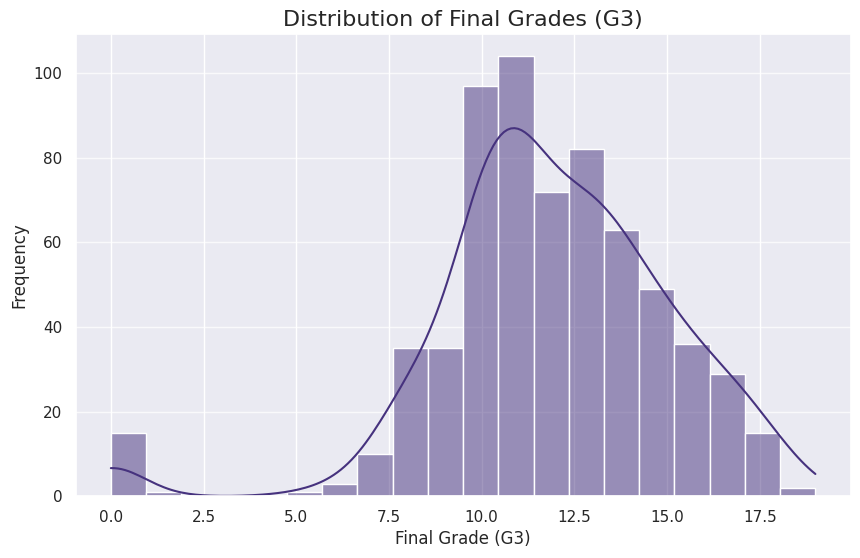

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="viridis")

plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['G3'], kde=True, bins=20)
plt.title('Distribution of Final Grades (G3)', fontsize=16)
plt.xlabel('Final Grade (G3)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

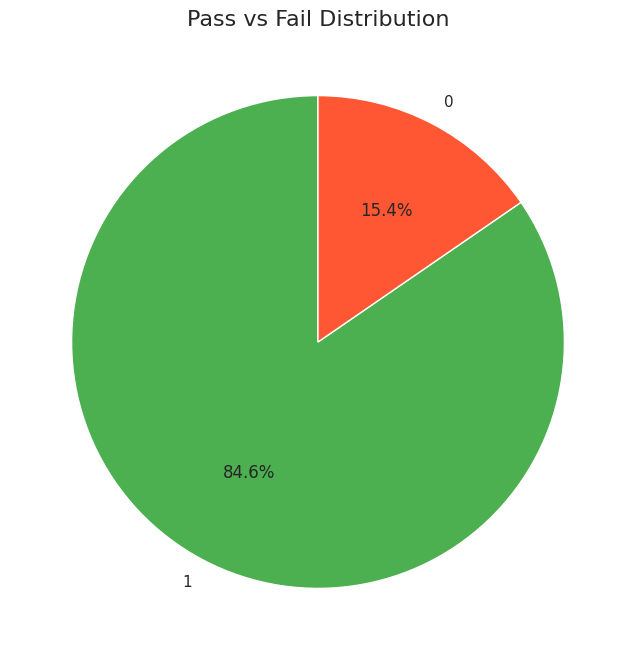

In [ ]:
plt.figure(figsize=(8, 8))
df_encoded['pass_fail'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF5733'])
plt.title('Pass vs Fail Distribution', fontsize=16)
plt.ylabel('')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

y = y.reset_index(drop=True)
df = pd.concat([X, y], axis=1)

print("Original DataFrame head:")
display(df.head())
print("\nOriginal DataFrame info:")
df.info()

Original DataFrame head:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,G1,G2,G3
0,0,0,18,1,0,0,4,4,2,2,...,False,True,False,False,False,True,False,0,11,11
1,0,0,17,1,0,1,1,1,1,2,...,False,False,False,False,False,False,False,9,11,11
2,0,0,15,1,1,1,1,1,1,2,...,False,False,False,True,False,True,False,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,True,False,True,False,False,True,False,14,14,14
4,0,0,16,1,0,1,3,3,1,2,...,False,False,True,False,False,False,False,11,13,13



Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   school             649 non-null    int64
 1   sex                649 non-null    int64
 2   age                649 non-null    int64
 3   address            649 non-null    int64
 4   famsize            649 non-null    int64
 5   Pstatus            649 non-null    int64
 6   Medu               649 non-null    int64
 7   Fedu               649 non-null    int64
 8   traveltime         649 non-null    int64
 9   studytime          649 non-null    int64
 10  failures           649 non-null    int64
 11  schoolsup          649 non-null    int64
 12  famsup             649 non-null    int64
 13  paid               649 non-null    int64
 14  activities         649 non-null    int64
 15  nursery            649 non-null    int64
 16  higher             649 non-null    i

In [ ]:
print("Missing values before handling:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nMissing values after handling (if any):")
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before handling:


,0



Missing values after handling (if any):


,0


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

numerical_cols = numerical_cols.drop(['G1', 'G2', 'G3'], errors='ignore')

df_encoded = df.copy()

for col in categorical_cols:
    if df[col].nunique() == 2:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        print(f"Label encoded column: {col}, Mapped to: {{'0': {le.classes_[0]}, '1': {le.classes_[1]}}}")
    else:
        df_encoded[col] = df_encoded[col].astype('category')
        df_encoded = pd.get_dummies(df_encoded, columns=[col], prefix=col, drop_first=True)
        print(f"One-hot encoded column: {col}")


print("\nDataFrame head after encoding:")
display(df_encoded.head())
print("\nDataFrame info after encoding:")
df_encoded.info()

Label encoded column: Mjob_health, Mapped to: {'0': False, '1': True}
Label encoded column: Mjob_other, Mapped to: {'0': False, '1': True}
Label encoded column: Mjob_services, Mapped to: {'0': False, '1': True}
Label encoded column: Mjob_teacher, Mapped to: {'0': False, '1': True}
Label encoded column: Fjob_health, Mapped to: {'0': False, '1': True}
Label encoded column: Fjob_other, Mapped to: {'0': False, '1': True}
Label encoded column: Fjob_services, Mapped to: {'0': False, '1': True}
Label encoded column: Fjob_teacher, Mapped to: {'0': False, '1': True}
Label encoded column: reason_home, Mapped to: {'0': False, '1': True}
Label encoded column: reason_other, Mapped to: {'0': False, '1': True}
Label encoded column: reason_reputation, Mapped to: {'0': False, '1': True}
Label encoded column: guardian_mother, Mapped to: {'0': False, '1': True}
Label encoded column: guardian_other, Mapped to: {'0': False, '1': True}

DataFrame head after encoding:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,G1,G2,G3
0,0,0,18,1,0,0,4,4,2,2,...,0,1,0,0,0,1,0,0,11,11
1,0,0,17,1,0,1,1,1,1,2,...,0,0,0,0,0,0,0,9,11,11
2,0,0,15,1,1,1,1,1,1,2,...,0,0,0,1,0,1,0,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,1,0,1,0,0,1,0,14,14,14
4,0,0,16,1,0,1,3,3,1,2,...,0,0,1,0,0,0,0,11,13,13



DataFrame info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   school             649 non-null    int64
 1   sex                649 non-null    int64
 2   age                649 non-null    int64
 3   address            649 non-null    int64
 4   famsize            649 non-null    int64
 5   Pstatus            649 non-null    int64
 6   Medu               649 non-null    int64
 7   Fedu               649 non-null    int64
 8   traveltime         649 non-null    int64
 9   studytime          649 non-null    int64
 10  failures           649 non-null    int64
 11  schoolsup          649 non-null    int64
 12  famsup             649 non-null    int64
 13  paid               649 non-null    int64
 14  activities         649 non-null    int64
 15  nursery            649 non-null    int64
 16  higher             649 non-nul

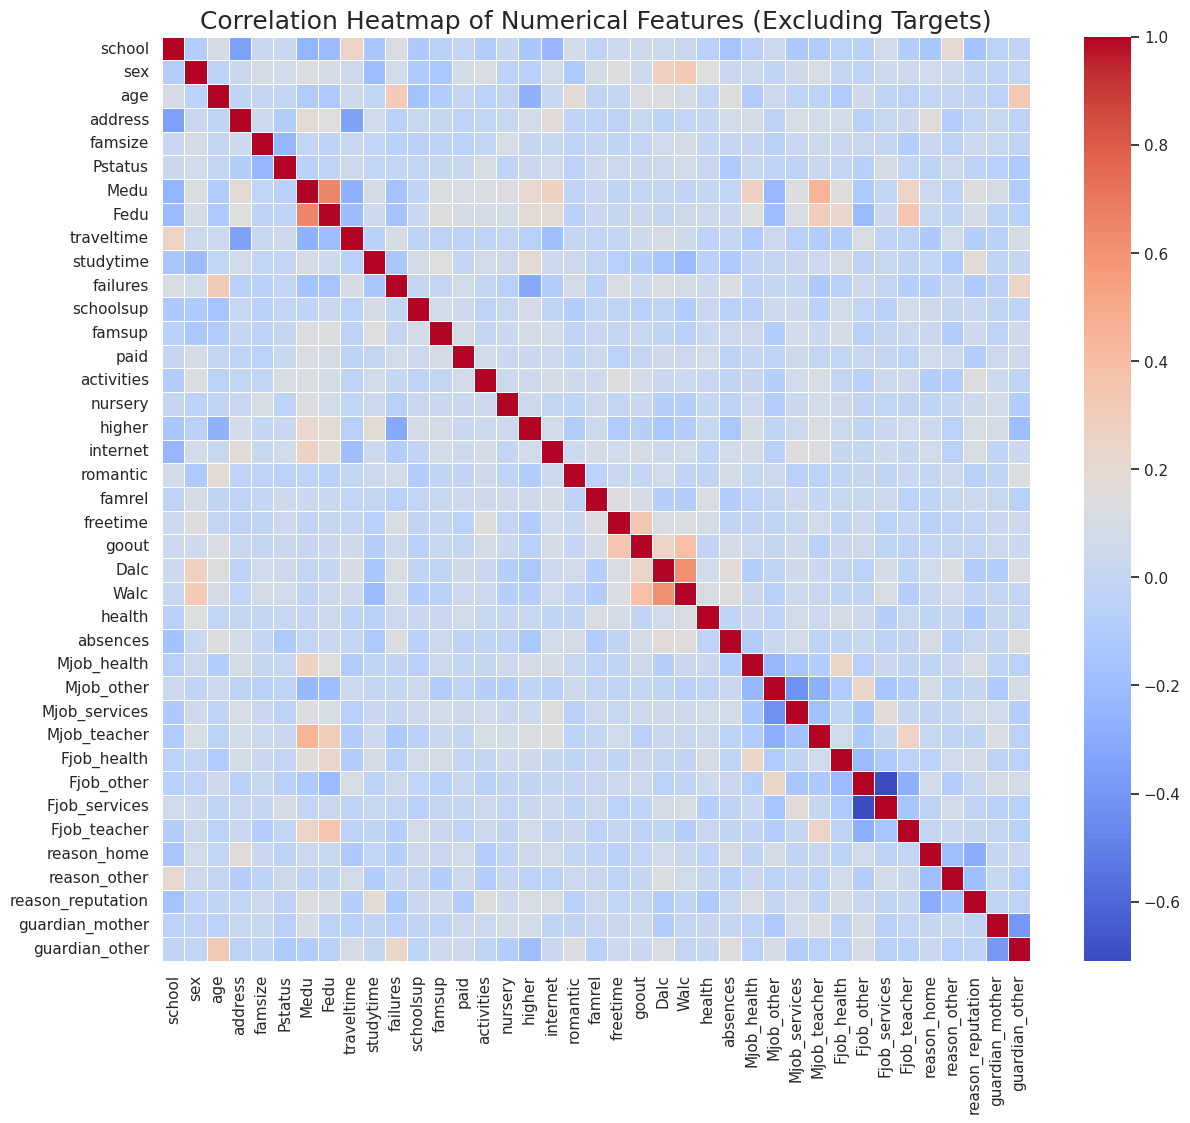

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="viridis")

numerical_df_for_corr = df_encoded.select_dtypes(include=['int64', 'float64', 'bool']).drop(columns=['G1', 'G2', 'G3', 'pass_fail'], errors='ignore')

plt.figure(figsize=(14, 12))
sns.heatmap(numerical_df_for_corr.corr(), cmap='coolwarm', fmt=".2f", linewidths=.5, annot=False)
plt.title('Correlation Heatmap of Numerical Features (Excluding Targets)', fontsize=18)
plt.show()

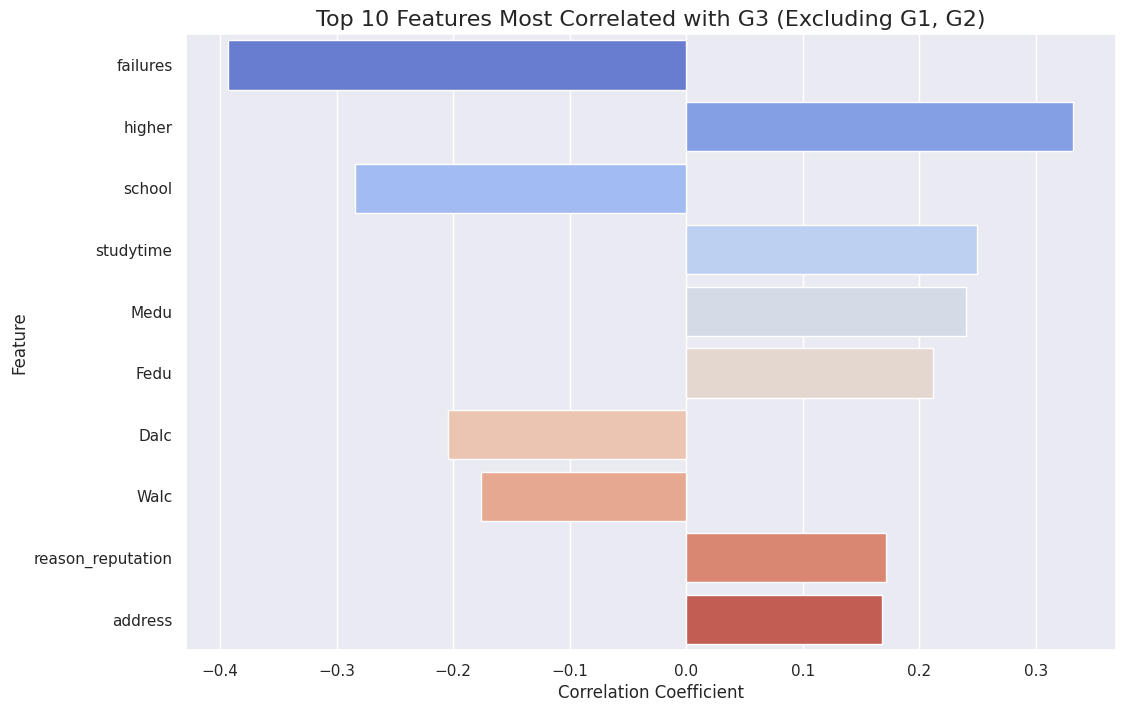

In [ ]:
correlations = df_encoded.corr(numeric_only=True)['G3'].sort_values(ascending=False)
filtered_correlations = correlations.drop(['G3', 'G1', 'G2'], errors='ignore')
top_10_corr = filtered_correlations.abs().sort_values(ascending=False).head(10).index
top_10_corr_values = correlations[top_10_corr]

plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_corr_values.values, y=top_10_corr_values.index, hue=top_10_corr_values.index, palette='coolwarm', legend=False)
plt.title('Top 10 Features Most Correlated with G3 (Excluding G1, G2)', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

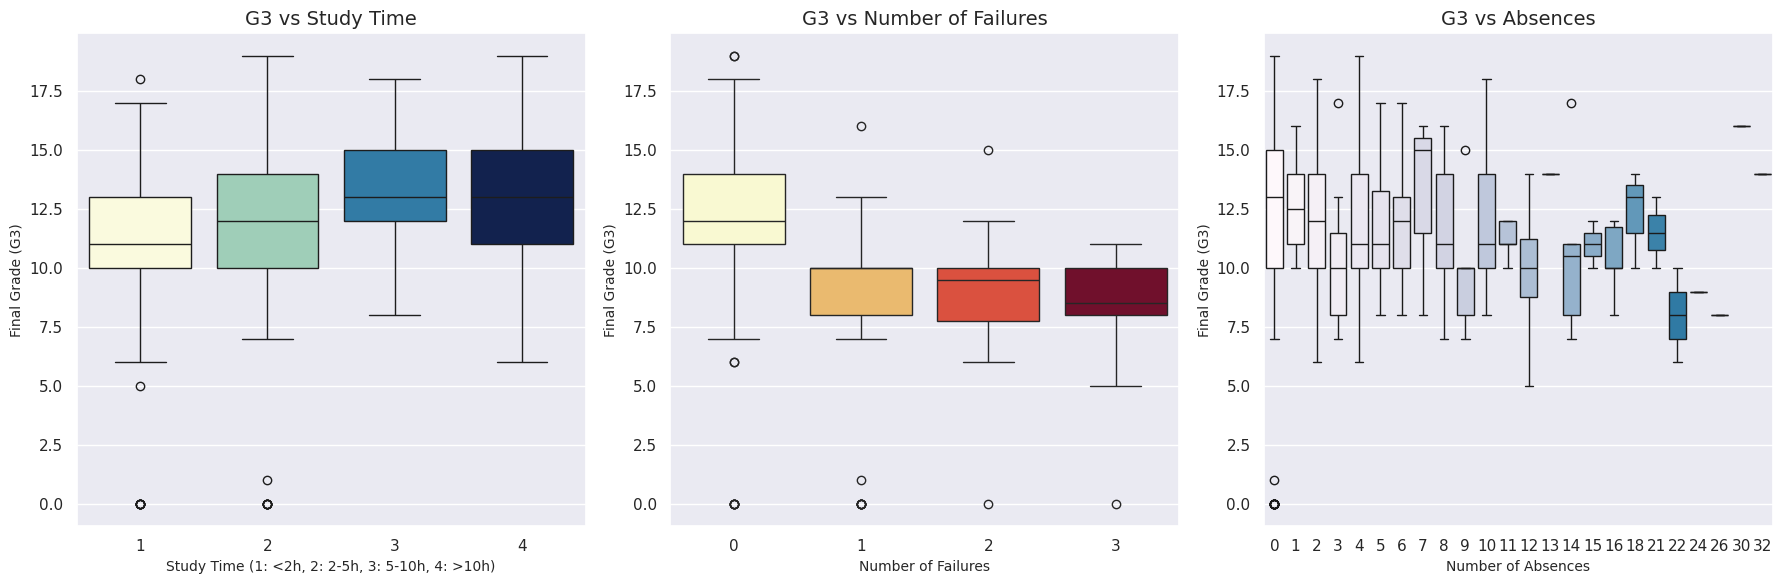

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='studytime', y='G3', data=df_encoded, palette='YlGnBu', hue='studytime', legend=False)
plt.title('G3 vs Study Time', fontsize=14)
plt.xlabel('Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)', fontsize=10)
plt.ylabel('Final Grade (G3)', fontsize=10)

plt.subplot(1, 3, 2)
sns.boxplot(x='failures', y='G3', data=df_encoded, palette='YlOrRd', hue='failures', legend=False)
plt.title('G3 vs Number of Failures', fontsize=14)
plt.xlabel('Number of Failures', fontsize=10)
plt.ylabel('Final Grade (G3)', fontsize=10)

plt.subplot(1, 3, 3)
sns.boxplot(x='absences', y='G3', data=df_encoded, palette='PuBu', hue='absences', legend=False)
plt.title('G3 vs Absences', fontsize=14)
plt.xlabel('Number of Absences', fontsize=10)
plt.ylabel('Final Grade (G3)', fontsize=10)

plt.tight_layout()
plt.show()

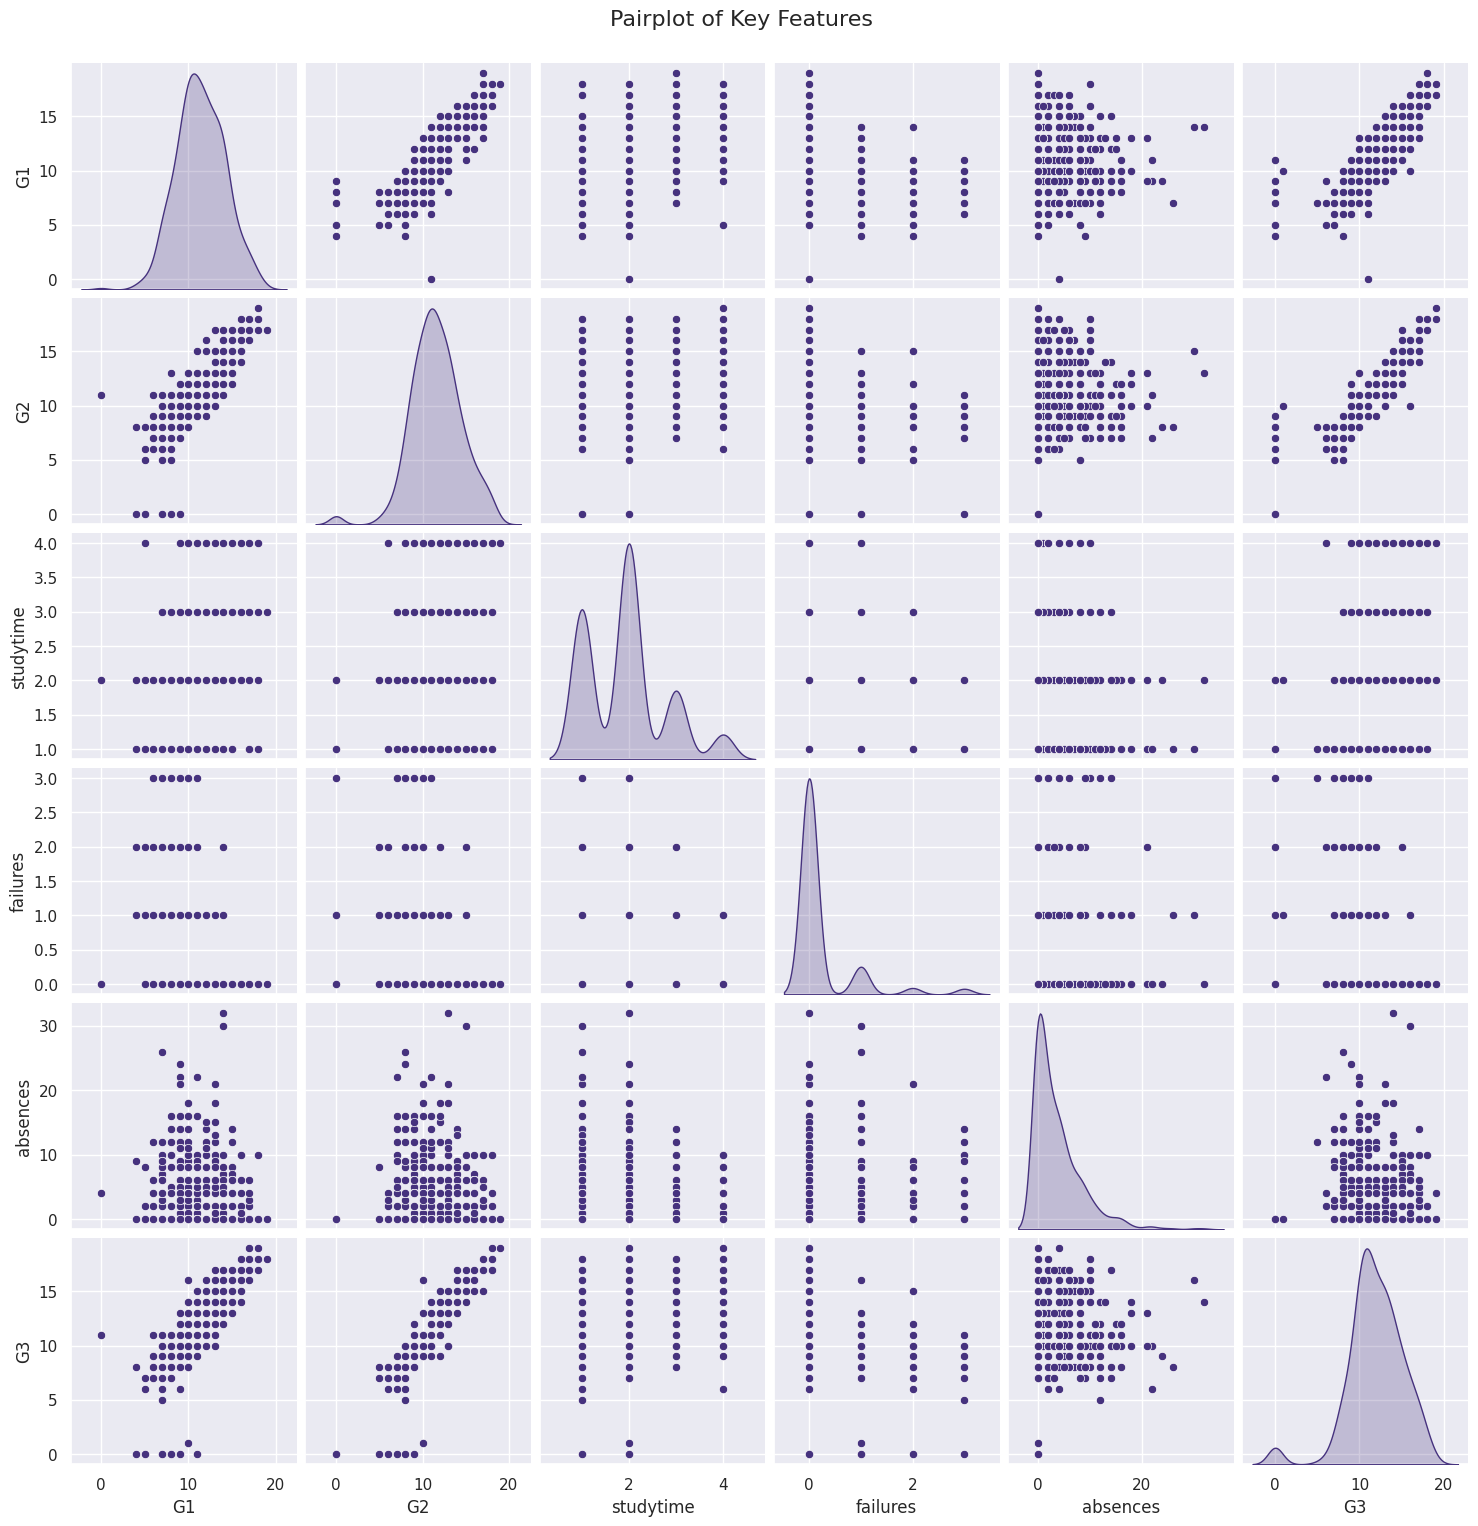

In [ ]:
key_features = ['G1', 'G2', 'studytime', 'failures', 'absences', 'G3']
existing_key_features = [f for f in key_features if f in df_encoded.columns]

if len(existing_key_features) > 1:
    sns.pairplot(df_encoded[existing_key_features], diag_kind='kde')
    plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=16)
    plt.show()
else:
    print(f"Not enough key features ({existing_key_features}) available for pairplot.")

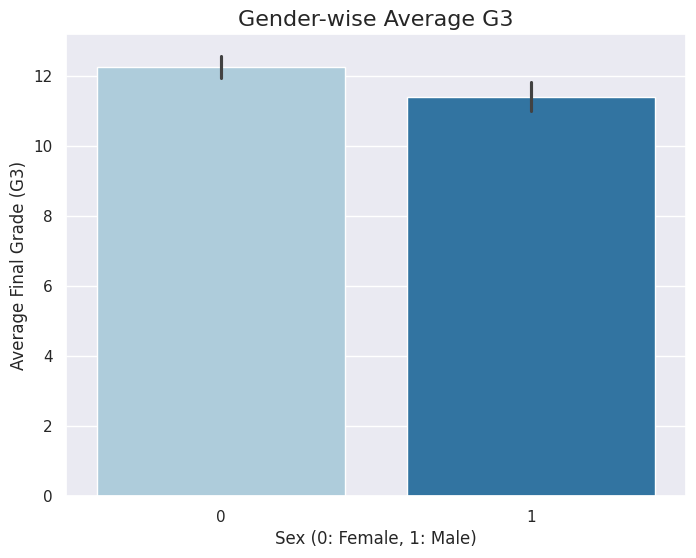

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='G3', data=df_encoded, estimator=lambda x: sum(x)/len(x), palette='Paired', hue='sex', legend=False)
plt.title('Gender-wise Average G3', fontsize=16)
plt.xlabel('Sex (0: Female, 1: Male)', fontsize=12)
plt.ylabel('Average Final Grade (G3)', fontsize=12)
plt.show()

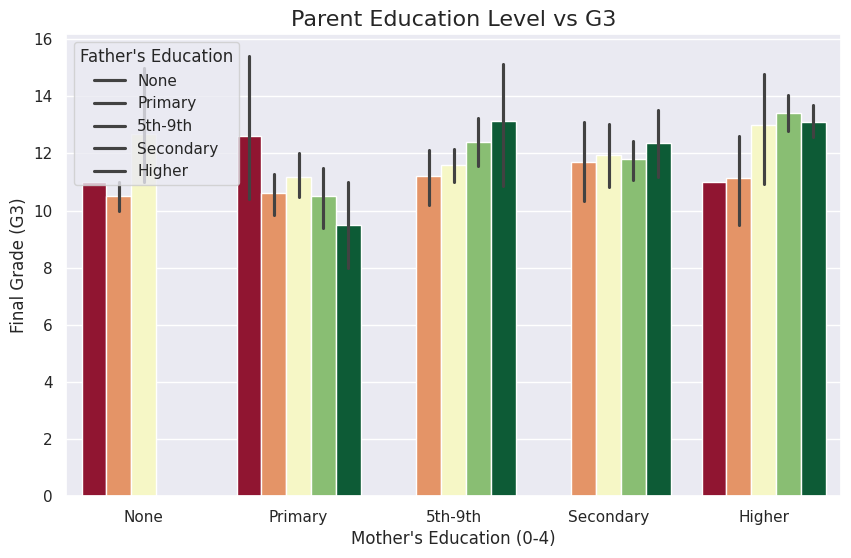

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Medu', y='G3', data=df_encoded, hue='Fedu', palette='RdYlGn')
plt.title('Parent Education Level vs G3', fontsize=16)
plt.xlabel('Mother\'s Education (0-4)', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['None', 'Primary', '5th-9th', 'Secondary', 'Higher'])
plt.legend(title='Father\'s Education', loc='upper left', labels=['None', 'Primary', '5th-9th', 'Secondary', 'Higher'])
plt.show()

## 3. MODEL TRAINING

## Model Architecture and Results

### Regression Models (Predicting G3)
-   **Models Evaluated**: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor.
-   **Metrics**: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2) score.
-   **Best Model**: **Gradient Boosting Regressor** achieved the highest R2 score of **0.2246**, indicating it best explains the variance in `G3`.

### Classification Models (Predicting Pass/Fail)
-   **Models Evaluated**: Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier, Support Vector Machine (SVM).
-   **Metrics**: Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
-   **Best Model**: **Support Vector Machine (SVM)** achieved the highest F1-score of **0.8966**, demonstrating a strong balance between precision and recall for classifying pass/fail status.

All trained models (`best_regression_model.joblib` and `best_classification_model.joblib`) were saved using `joblib`.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Training Regression Models ---")

regression_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

regression_results = {}

for name, model in regression_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred_reg = model.predict(X_test_reg_scaled)

    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)

    regression_results[name] = {'model': model, 'mae': mae, 'rmse': rmse, 'r2': r2}

    print(f"{name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

best_reg_model_name = max(regression_results, key=lambda k: regression_results[k]['r2'])
best_reg_model = regression_results[best_reg_model_name]['model']
print(f"\nBest Regression Model: {best_reg_model_name} with R2 score: {regression_results[best_reg_model_name]['r2']:.4f}")

joblib.dump(best_reg_model, 'best_regression_model.joblib')
print("Best regression model saved as 'best_regression_model.joblib'")


--- Training Regression Models ---

Training Linear Regression...
Linear Regression - MAE: 2.1564, RMSE: 2.8618, R2: 0.1602

Training Random Forest Regressor...
Random Forest Regressor - MAE: 2.0606, RMSE: 2.8226, R2: 0.1830

Training Gradient Boosting Regressor...
Gradient Boosting Regressor - MAE: 2.0477, RMSE: 2.7498, R2: 0.2246

Best Regression Model: Gradient Boosting Regressor with R2 score: 0.2246
Best regression model saved as 'best_regression_model.joblib'


In [ ]:
print("\n--- Training Classification Models ---")

classification_models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

classification_results = {}

for name, model in classification_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_cls_scaled, y_train_cls)
    y_pred_cls = model.predict(X_test_cls_scaled)

    accuracy = accuracy_score(y_test_cls, y_pred_cls)
    precision = precision_score(y_test_cls, y_pred_cls)
    recall = recall_score(y_test_cls, y_pred_cls)
    f1 = f1_score(y_test_cls, y_pred_cls)
    cm = confusion_matrix(y_test_cls, y_pred_cls)

    classification_results[name] = {'model': model, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'confusion_matrix': cm}

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

best_cls_model_name = max(classification_results, key=lambda k: classification_results[k]['f1'])
best_cls_model = classification_results[best_cls_model_name]['model']
print(f"\nBest Classification Model: {best_cls_model_name} with F1 score: {classification_results[best_cls_model_name]['f1']:.4f}")

joblib.dump(best_cls_model, 'best_classification_model.joblib')
print("Best classification model saved as 'best_classification_model.joblib'")


--- Training Classification Models ---

Training Logistic Regression...
Logistic Regression - Accuracy: 0.7769, Precision: 0.8649, Recall: 0.8727, F1: 0.8688
Confusion Matrix:
[[ 5 15]
 [14 96]]

Training Random Forest Classifier...
Random Forest Classifier - Accuracy: 0.8154, Precision: 0.8583, Recall: 0.9364, F1: 0.8957
Confusion Matrix:
[[  3  17]
 [  7 103]]

Training Gradient Boosting Classifier...
Gradient Boosting Classifier - Accuracy: 0.7846, Precision: 0.8727, Recall: 0.8727, F1: 0.8727
Confusion Matrix:
[[ 6 14]
 [14 96]]

Training SVM...
SVM - Accuracy: 0.8154, Precision: 0.8525, Recall: 0.9455, F1: 0.8966
Confusion Matrix:
[[  2  18]
 [  6 104]]

Best Classification Model: SVM with F1 score: 0.8966
Best classification model saved as 'best_classification_model.joblib'


## 4. FEATURE IMPORTANCE

## Feature Importance Summary
-   **Random Forest Feature Importances**: For both regression and classification, `failures` consistently appeared as a highly important feature. For classification, `higher` (desire for higher education) and `school` also played significant roles.
-   **SHAP (SHapley Additive exPlanations) Summary Plot**: Generated for the best classification model (SVM), the SHAP plot provided deeper insights into how each feature influences the model's output, indicating which features drive predictions towards 'pass' or 'fail'.


--- Feature Importances: Random Forest Regressor ---


/tmp/ipykernel_563/2225105707.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_reg.head(15).values, y=feature_importances_reg.head(15).index, palette='Blues_d')


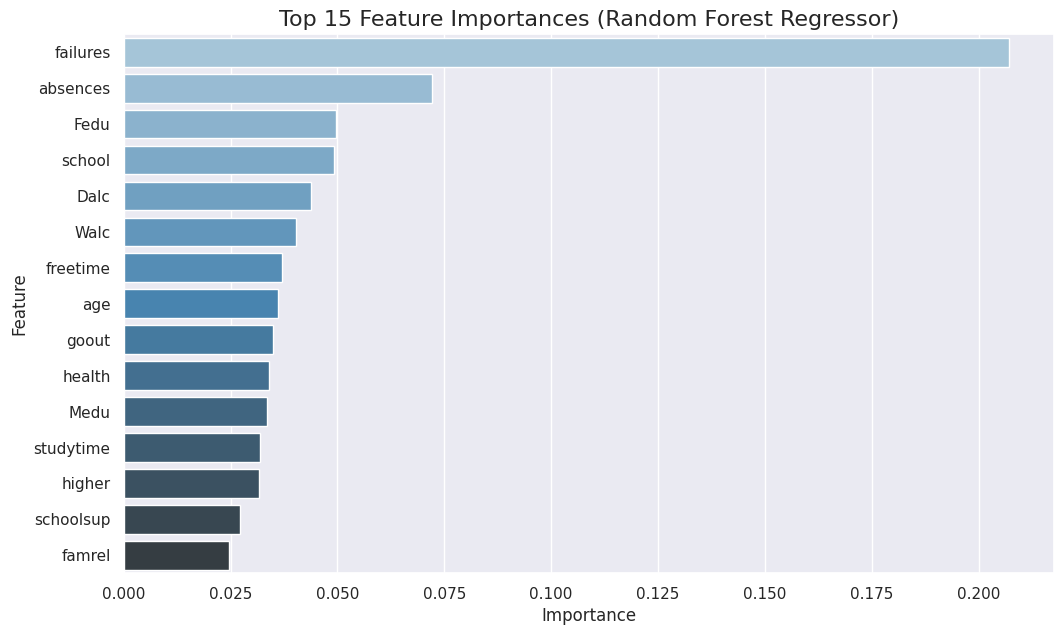


--- Feature Importances: Random Forest Classifier ---


/tmp/ipykernel_563/2225105707.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_cls.head(15).values, y=feature_importances_cls.head(15).index, palette='Greens_d')


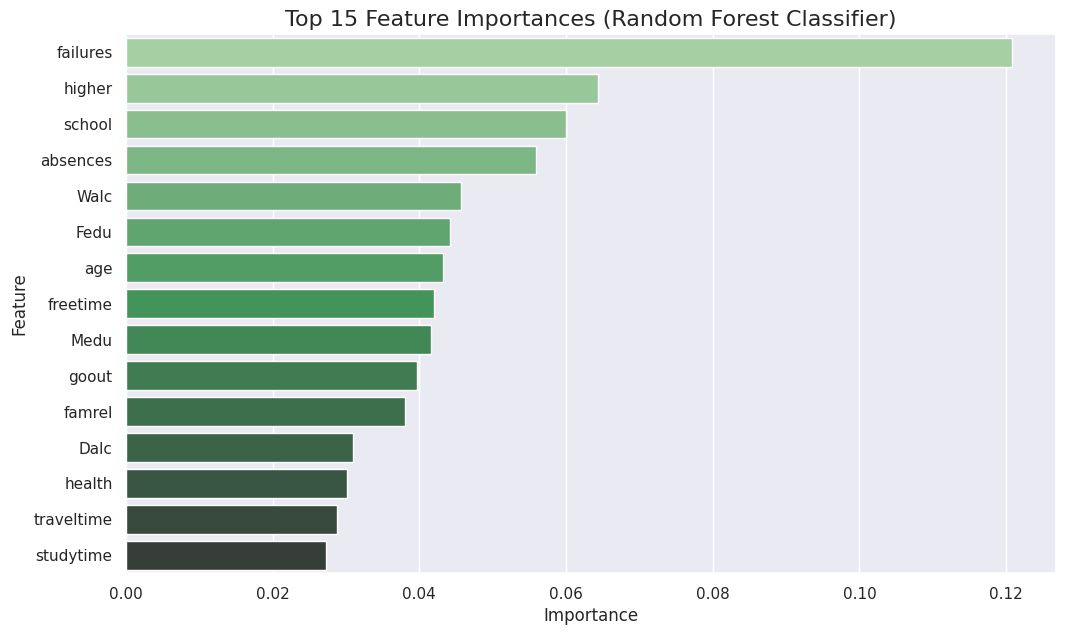

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sns.set_theme(style="darkgrid", palette="viridis")

print("\n--- Feature Importances: Random Forest Regressor ---")
rf_regressor = regression_models['Random Forest Regressor']

if hasattr(rf_regressor, 'feature_importances_'):
    feature_importances_reg = pd.Series(rf_regressor.feature_importances_, index=X_train_reg_scaled.columns).sort_values(ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=feature_importances_reg.head(15).values, y=feature_importances_reg.head(15).index, palette='Blues_d')
    plt.title('Top 15 Feature Importances (Random Forest Regressor)', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.show()
else:
    print("Random Forest Regressor does not have feature_importances_ attribute.")

print("\n--- Feature Importances: Random Forest Classifier ---")
rf_classifier = classification_models['Random Forest Classifier']

if hasattr(rf_classifier, 'feature_importances_'):
    feature_importances_cls = pd.Series(rf_classifier.feature_importances_, index=X_train_cls_scaled.columns).sort_values(ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=feature_importances_cls.head(15).values, y=feature_importances_cls.head(15).index, palette='Greens_d')
    plt.title('Top 15 Feature Importances (Random Forest Classifier)', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.show()
else:
    print("Random Forest Classifier does not have feature_importances_ attribute.")


--- SHAP Summary Plot for Best Classification Model ---
Using KernelExplainer for SVM. This may take some time.


  0%|          | 0/100 [00:00<?, ?it/s]

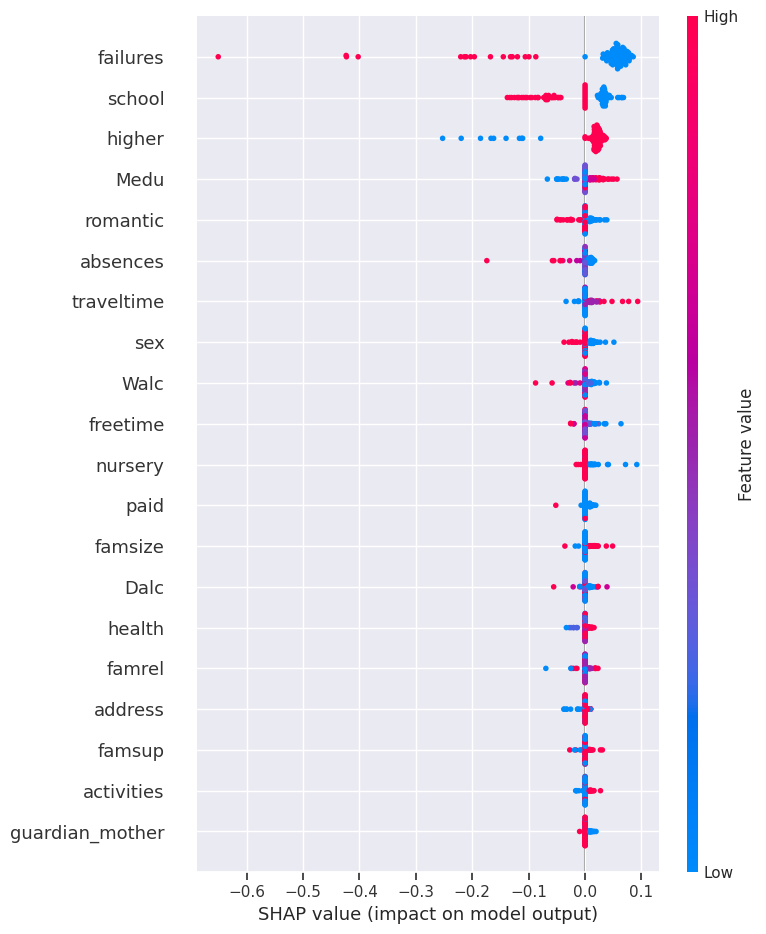

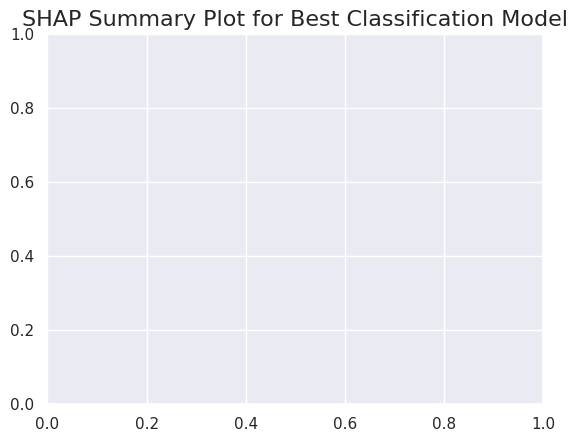

In [ ]:
print("\n--- SHAP Summary Plot for Best Classification Model ---")

if 'Random Forest' in best_cls_model_name or 'Gradient Boosting' in best_cls_model_name:
    explainer = shap.TreeExplainer(best_cls_model)
    shap_values = explainer.shap_values(X_test_cls_scaled)
    shap.summary_plot(shap_values[1], X_test_cls_scaled, feature_names=X_test_cls_scaled.columns)
else:
    print(f"Using KernelExplainer for {best_cls_model_name}. This may take some time.")
    sample_size = min(100, X_test_cls_scaled.shape[0])

    sampled_X_test_np = shap.sample(X_test_cls_scaled.values, sample_size)
    background_data_np = shap.sample(X_train_cls_scaled.values, 50)

    explainer = shap.KernelExplainer(best_cls_model.predict_proba, background_data_np)
    shap_values = explainer.shap_values(sampled_X_test_np)
    shap.summary_plot(shap_values[:, :, 1], sampled_X_test_np, feature_names=list(X_test_cls_scaled.columns))

plt.title('SHAP Summary Plot for Best Classification Model', fontsize=16)
plt.show()

## 5. INTERACTIVE FRONTEND INPUT PAGE (ipywidgets)

## Interactive Frontend (ipywidgets)
An interactive user interface was developed using `ipywidgets` to allow real-time predictions based on user-inputted student information. This frontend:
-   Provides various input widgets (radio buttons, dropdowns, sliders) for student features.
-   Transforms input data to match model training format.
-   Uses the best regression model to predict `G3` and the best classification model to predict pass/fail status.
-   Displays predicted `G3`, pass/fail status, and classification confidence with a visual progress bar.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import Layout, Box, VBox, HBox, Button, HTML
import joblib
import pandas as pd
import numpy as np

best_reg_model = joblib.load('best_regression_model.joblib')
best_cls_model = joblib.load('best_classification_model.joblib')

scaler_inference = StandardScaler()
columns_to_scale_inference = X.select_dtypes(include=['int64', 'float64']).columns

scaler_inference.fit(X[columns_to_scale_inference])

style = {'description_width': 'initial'}
layout_half = Layout(width='48%')
layout_full = Layout(width='98%')

def create_int_slider(description, min_val, max_val, step, default_val):
    return widgets.IntSlider(
        description=description,
        min=min_val,
        max=max_val,
        step=step,
        value=default_val,
        style=style,
        layout=layout_full
    )

def create_dropdown(description, options, default_val):
    return widgets.Dropdown(
        description=description,
        options=options,
        value=default_val,
        style=style,
        layout=layout_full
    )

def create_radio_buttons(description, options, default_val):
    return widgets.RadioButtons(
        description=description,
        options=options,
        value=default_val,
        style=style,
        layout=Layout(width='auto')
    )

w_school = create_radio_buttons('School:', options={'GP': 0, 'MS': 1}, default_val=0)
w_sex = create_radio_buttons('Sex:', options={'Female': 0, 'Male': 1}, default_val=0)
w_address = create_radio_buttons('Address Type:', options={'Rural': 0, 'Urban': 1}, default_val=1)
w_famsize = create_radio_buttons('Family Size:', options={'GT3': 0, 'LE3': 1}, default_val=0)
w_pstatus = create_radio_buttons('Parents Cohabitation Status:', options={'Apart': 0, 'Together': 1}, default_val=1)
w_schoolsup = create_radio_buttons('School Support:', options={'No': 0, 'Yes': 1}, default_val=0)
w_famsup = create_radio_buttons('Family Support:', options={'No': 0, 'Yes': 1}, default_val=0)
w_paid = create_radio_buttons('Paid Classes:', options={'No': 0, 'Yes': 1}, default_val=0)
w_activities = create_radio_buttons('Extracurricular Activities:', options={'No': 0, 'Yes': 1}, default_val=0)
w_nursery = create_radio_buttons('Attended Nursery School:', options={'No': 0, 'Yes': 1}, default_val=1)
w_higher = create_radio_buttons('Wants Higher Education:', options={'No': 0, 'Yes': 1}, default_val=1)
w_internet = create_radio_buttons('Internet Access:', options={'No': 0, 'Yes': 1}, default_val=1)
w_romantic = create_radio_buttons('In a Romantic Relationship:', options={'No': 0, 'Yes': 1}, default_val=0)

w_mjob = create_dropdown('Mother Job:', options={'teacher': 'Mjob_teacher', 'health': 'Mjob_health', 'services': 'Mjob_services', 'at_home': 'Mjob_at_home', 'other': 'Mjob_other'}, default_val='Mjob_other')
w_fjob = create_dropdown('Father Job:', options={'teacher': 'Fjob_teacher', 'health': 'Fjob_health', 'services': 'Fjob_services', 'at_home': 'Fjob_at_home', 'other': 'Fjob_other'}, default_val='Fjob_other')
w_reason = create_dropdown('Reason to choose school:', options={'home': 'reason_home', 'reputation': 'reason_reputation', 'course': 'reason_course', 'other': 'reason_other'}, default_val='reason_course')
w_guardian = create_dropdown('Guardian:', options={'mother': 'guardian_mother', 'father': 'guardian_father', 'other': 'guardian_other'}, default_val='guardian_mother')

w_age = create_int_slider('Age:', 15, 22, 1, 17)
w_medu = create_int_slider('Mother Education (0-4):', 0, 4, 1, 2)
w_fedu = create_int_slider('Father Education (0-4):', 0, 4, 1, 2)
w_traveltime = create_int_slider('Travel Time (1-4):', 1, 4, 1, 2)
w_studytime = create_int_slider('Study Time (1-4):', 1, 4, 1, 2)
w_failures = create_int_slider('Past Class Failures:', 0, 4, 1, 0)
w_famrel = create_int_slider('Family Relationship Quality (1-5):', 1, 5, 1, 4)
w_freetime = create_int_slider('Free Time After School (1-5):', 1, 5, 1, 3)
w_goout = create_int_slider('Going Out with Friends (1-5):', 1, 5, 1, 3)
w_dalc = create_int_slider('Workday Alcohol Consumption (0-5):', 1, 5, 1, 1)
w_walc = create_int_slider('Weekend Alcohol Consumption (0-5):', 1, 5, 1, 1)
w_health = create_int_slider('Current Health Status (1-5):', 1, 5, 1, 3)
w_absences = create_int_slider('Number of School Absences (0-93):', 0, 20, 1, 0)

w_g1 = create_int_slider('G1 (1st Period Grade):', 0, 20, 1, 10)
w_g2 = create_int_slider('G2 (2nd Period Grade):', 0, 20, 1, 10)

predict_button = Button(
    description='Predict',
    button_style='success',
    tooltip='Click to predict student performance',
    layout=Layout(width='auto', flex='1 1 auto', margin='10px 0 0 0')
)

output_reg = widgets.Output()
output_cls = widgets.Output()

def get_one_hot_columns(prefix, selected_value, all_columns):
    encoded_cols = [col for col in all_columns if col.startswith(prefix + '_')]
    result = {col: False for col in encoded_cols}
    if selected_value in result:
        result[selected_value] = True
    elif prefix + '_' + selected_value.split('_')[1] in result:
        result[selected_value] = True
    return result

model_features = X_train_reg_scaled.columns

def on_predict_button_clicked(b):
    with output_reg:
        output_reg.clear_output()
        input_data = {
            'school': w_school.value,
            'sex': w_sex.value,
            'age': w_age.value,
            'address': w_address.value,
            'famsize': w_famsize.value,
            'Pstatus': w_pstatus.value,
            'Medu': w_medu.value,
            'Fedu': w_fedu.value,
            'traveltime': w_traveltime.value,
            'studytime': w_studytime.value,
            'failures': w_failures.value,
            'schoolsup': w_schoolsup.value,
            'famsup': w_famsup.value,
            'paid': w_paid.value,
            'activities': w_activities.value,
            'nursery': w_nursery.value,
            'higher': w_higher.value,
            'internet': w_internet.value,
            'romantic': w_romantic.value,
            'famrel': w_famrel.value,
            'freetime': w_freetime.value,
            'goout': w_goout.value,
            'Dalc': w_dalc.value,
            'Walc': w_walc.value,
            'health': w_health.value,
            'absences': w_absences.value,
        }

        mjob_encoded = get_one_hot_columns('Mjob', w_mjob.value, model_features)
        fjob_encoded = get_one_hot_columns('Fjob', w_fjob.value, model_features)
        reason_encoded = get_one_hot_columns('reason', w_reason.value, model_features)
        guardian_encoded = get_one_hot_columns('guardian', w_guardian.value, model_features)

        input_data.update(mjob_encoded)
        input_data.update(fjob_encoded)
        input_data.update(reason_encoded)
        input_data.update(guardian_encoded)

        input_df = pd.DataFrame(columns=model_features)
        input_df.loc[0] = 0

        for feature, value in input_data.items():
            if feature in input_df.columns:
                input_df.loc[0, feature] = value
            if isinstance(input_df.loc[0, feature], bool):
                 input_df.loc[0, feature] = bool(value)

        numerical_cols_for_scaling = list(columns_to_scale_inference)

        input_df_scaled = input_df.copy()
        input_df_scaled[numerical_cols_for_scaling] = scaler_inference.transform(input_df_scaled[numerical_cols_for_scaling])

        predicted_g3 = best_reg_model.predict(input_df_scaled)[0]
        predicted_pass_fail = best_cls_model.predict(input_df_scaled)[0]
        predicted_proba = best_cls_model.predict_proba(input_df_scaled)[0]

        pass_status = 'Pass' if predicted_pass_fail == 1 else 'Fail'
        color = '#4CAF50' if predicted_pass_fail == 1 else '#FF5733'
        confidence = max(predicted_proba) * 100

        display(HTML(f"""
        <div style="border: 2px solid #3498db; border-radius: 8px; padding: 15px; margin-top: 20px; background-color: #000000">
            <h3 style="color: #2c3e50; text-align: center;">Prediction Results</h3>
            <p style="font-size: 1.1em;"><b>Predicted Final Grade (G3):</b> <span style="color: #2980b9; font-weight: bold;">{predicted_g3:.2f}</span></p>
            <p style="font-size: 1.1em;"><b>Pass/Fail Status:</b> <span style="color: {color}; font-weight: bold;">{pass_status}</span></p>
            <p style="font-size: 1.1em;"><b>Confidence:</b> <span style="color: #2980b9; font-weight: bold;">{confidence:.2f}%</span></p>
            <div style="width: 100%; background-color: #ddd; border-radius: 5px; margin-top: 10px;">
                <div style="width: {min(predicted_g3/20*100, 100)}%; background-color: {color}; text-align: center; color: white; border-radius: 5px;">{predicted_g3:.1f}/20</div>
            </div>
        </div>
        """))

predict_button.on_click(on_predict_button_clicked)

input_widgets_left = VBox([
    w_school, w_sex, w_age, w_address, w_famsize, w_pstatus,
    w_medu, w_fedu, w_traveltime, w_studytime, w_failures, w_absences
])

input_widgets_right = VBox([
    w_schoolsup, w_famsup, w_paid, w_activities, w_nursery, w_higher,
    w_internet, w_romantic, w_famrel, w_freetime, w_goout,
    w_dalc, w_walc, w_health
])

mjob_fjob_reason_guardian = VBox([
    w_mjob, w_fjob, w_reason, w_guardian
])

input_form = VBox([
    HTML('<h3 style="color: #2c3e50;">Student Information:</h3>'),
    HBox([input_widgets_left, input_widgets_right]),
    mjob_fjob_reason_guardian,
    predict_button,
    output_reg
], layout=Layout(border='2px solid #3498db', padding='15px', border_radius='10px', background_color='#ecf0f1'))

display(input_form)

## Conclusion
This project successfully developed and evaluated machine learning models for student performance prediction. The Gradient Boosting Regressor and SVM were identified as the best-performing models for regression and classification tasks, respectively. Feature importance analysis provided valuable insights into critical factors influencing student outcomes. The interactive frontend serves as a practical tool for quick assessment, demonstrating the real-world application of the developed models.